<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Mini_Batch_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Batch Gradient Descent

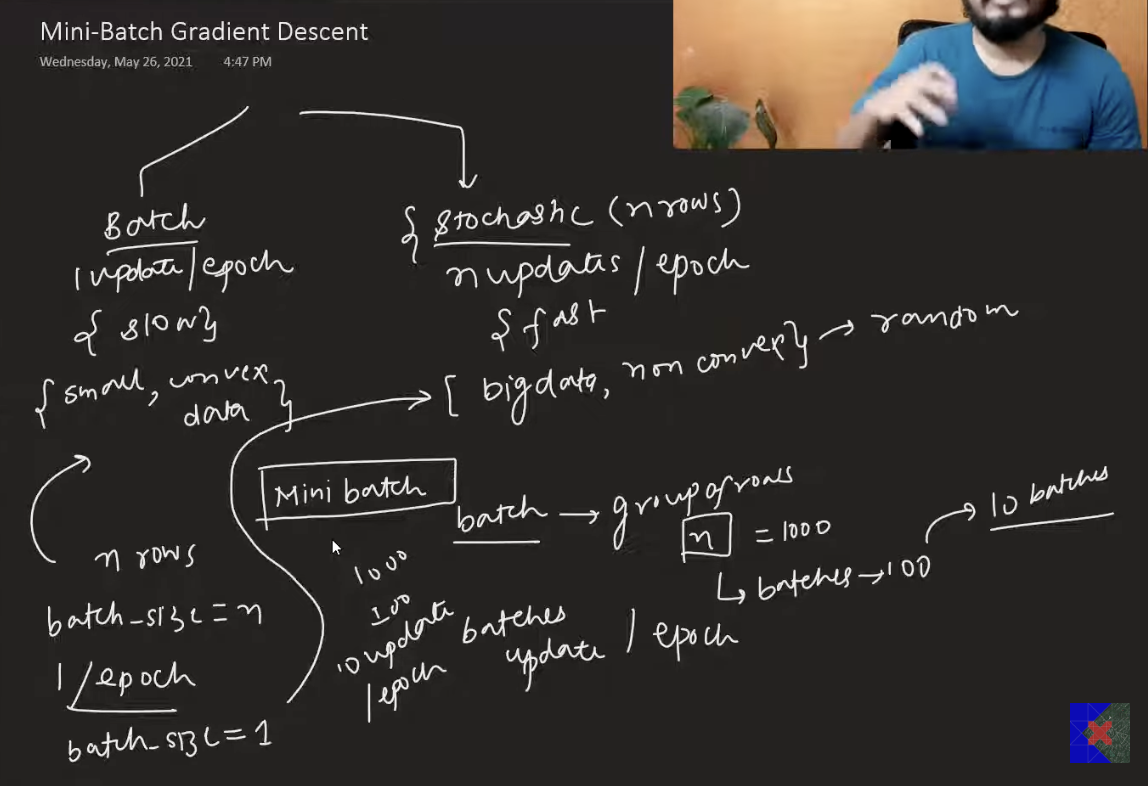

In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
X,y = load_diabetes(return_X_y=True)

In [4]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [7]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [8]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.4399338661568968

In [12]:
import random

class MBGDRegressor:
  def __init__(self, batch_size=30,learning_rate=0.01, epochs=100):
    self.coef_ = None
    self.intercept_ = None
    self.lr = learning_rate
    self.epochs = epochs
    self.batch_size = batch_size

  def fit(self, X_train, y_train):

    # initialize your all coefs and intercept
    self.intercept_ = 0
    # X_train shape = n and n+1 = no. of coefs
    self.coef_ = np.ones(X_train.shape[1])

    # loop and update all coefs and intercept
    for i in range(self.epochs):

      for j in range(int(X_train.shape[0]/self.batch_size)):

        # randomly select rows
        idx = random.sample(range(X_train.shape[0]), self.batch_size)

        # INTERCEPT CALCULATION - Vectorization
        y_hat = np.dot(X_train[idx], self.coef_) + self.intercept_
        intercept_der = -2 * np.mean(y_train[idx] - y_hat)
        self.intercept_  = self.intercept_ - (self.lr * intercept_der)

        # COEFFICIENT CALCULATION
        coef_der = -2 * np.dot((y_train[idx] - y_hat), X_train[idx])
        self.coef_ = self.coef_ - (self.lr * coef_der)


    print(self.intercept_, self.coef_)

  def predict(self, X_test):
    return np.dot(X_test, self.coef_) + self.intercept_


In [21]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50), learning_rate=0.01, epochs=50)

In [22]:
mbr.fit(X_train, y_train)

154.12531940523453 [  52.38413256  -66.07411825  341.65708638  248.07371108   18.76446546
  -30.49739484 -165.75174915  126.85745309  322.12026007  133.45649305]


In [23]:
y_pred = mbr.predict(X_test)

In [24]:
r2_score(y_test, y_pred)

0.43161059144776104

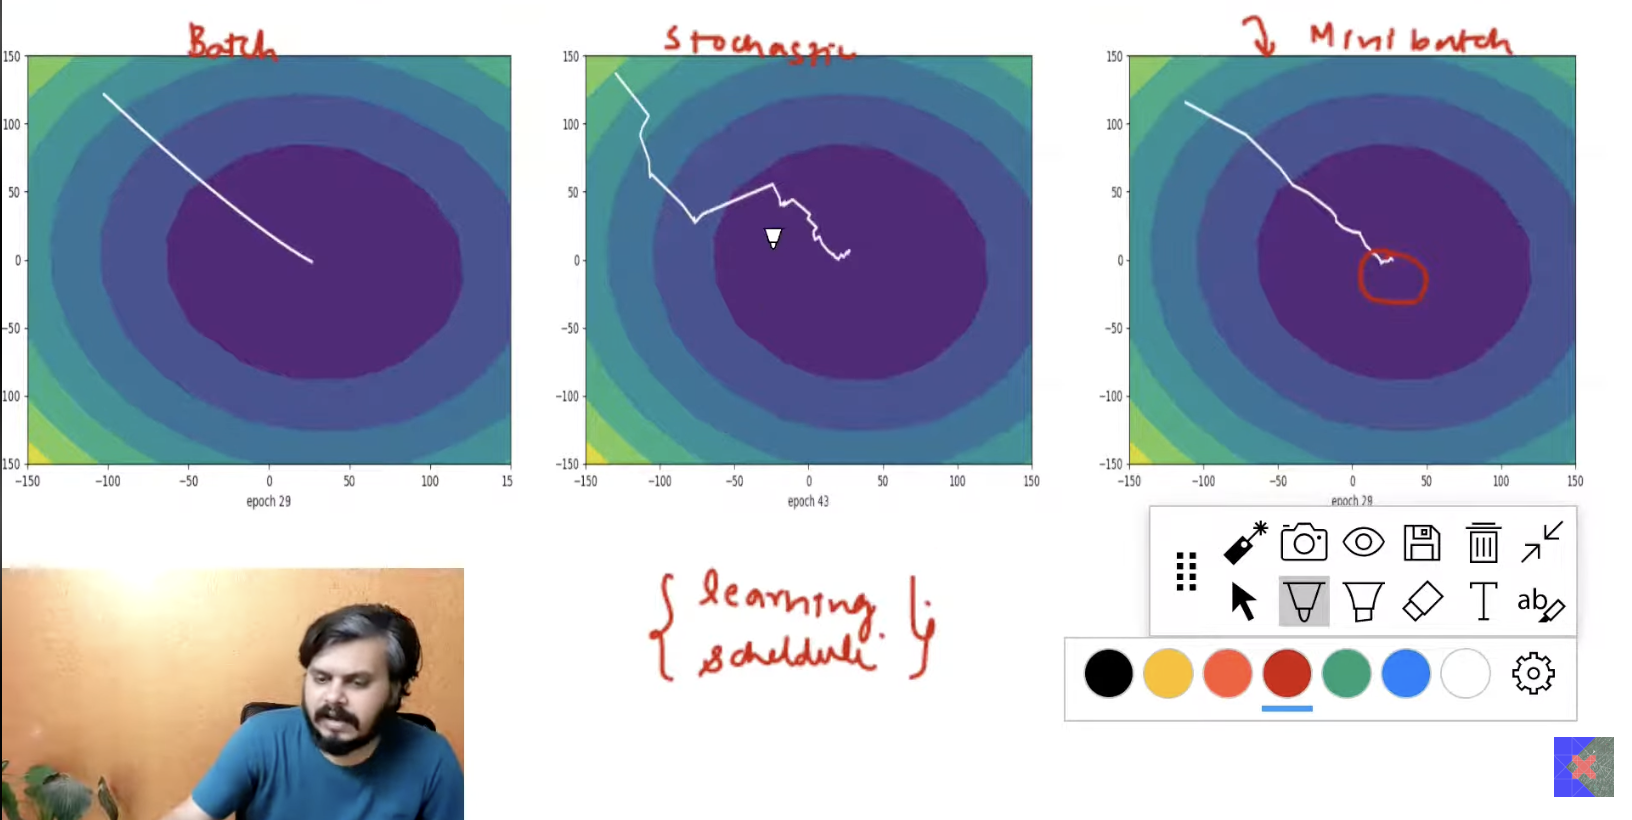

# Using Scikit learn

In [25]:
from sklearn.linear_model import SGDRegressor

In [32]:
sgd = SGDRegressor(learning_rate='constant', eta0=0.1)

In [33]:
batch_size = 35
# jugaad
for i in range(100): # 100 epoch
  idx = random.sample(range(X_train.shape[0]), batch_size)
  # we can set subset of X train and y train
  sgd.partial_fit(X_train[idx], y_train[idx])

In [34]:
sgd.coef_

array([  51.28224687,  -78.51598796,  348.22009256,  232.23107872,
         15.26961794,  -21.78848988, -181.50531154,  136.95386209,
        310.61565299,  126.27071618])

In [35]:
y_pred = sgd.predict(X_test)

In [36]:
r2_score(y_test, y_pred)

0.42708033551372737